In [1]:
!pip install scikit-learn



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix

df = pd.read_excel('catalog_products.xlsx')

num_cols = [col for col in df.columns if pd.api.types.is_numeric_dtype(df[col])]

#1
print("Форма:", df.shape)
print("\nТипы данных:")
print(df.dtypes)
print("\nПропуски:")
print(df.isnull().sum())
print("\nПервые 5 строк:")
print(df.head())




Форма: (10000, 50)

Типы данных:
col_1       str
col_2     int64
col_3     int64
col_4       str
col_5     int64
col_6     int64
col_7       str
col_8     int64
col_9     int64
col_10      str
col_11    int64
col_12    int64
col_13      str
col_14    int64
col_15    int64
col_16      str
col_17    int64
col_18    int64
col_19      str
col_20    int64
col_21    int64
col_22      str
col_23    int64
col_24    int64
col_25      str
col_26    int64
col_27    int64
col_28      str
col_29    int64
col_30    int64
col_31      str
col_32    int64
col_33    int64
col_34      str
col_35    int64
col_36    int64
col_37      str
col_38    int64
col_39    int64
col_40      str
col_41    int64
col_42    int64
col_43      str
col_44    int64
col_45    int64
col_46      str
col_47    int64
col_48    int64
col_49      str
col_50    int64
dtype: object

Пропуски:
col_1     0
col_2     0
col_3     0
col_4     0
col_5     0
col_6     0
col_7     0
col_8     0
col_9     0
col_10    0
col_11    0
col_12    

In [3]:
#2
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].mean())

df.dropna(subset=['col_1', 'col_7'], inplace=True)
print("После очистки:", df.shape)

После очистки: (10000, 50)


In [4]:
#3
df['total_value'] = df['col_2'] * df['col_3']
df['log_price'] = np.log(df['col_2'])
df['double_stock'] = df['col_3'] * 2
print(df[['total_value', 'log_price', 'double_stock']].head())


   total_value  log_price  double_stock
0       230886   6.635947           606
1         6460   5.247024            68
2         1422   6.566672             4
3       175208   6.182085           724
4       142935   6.597146           390


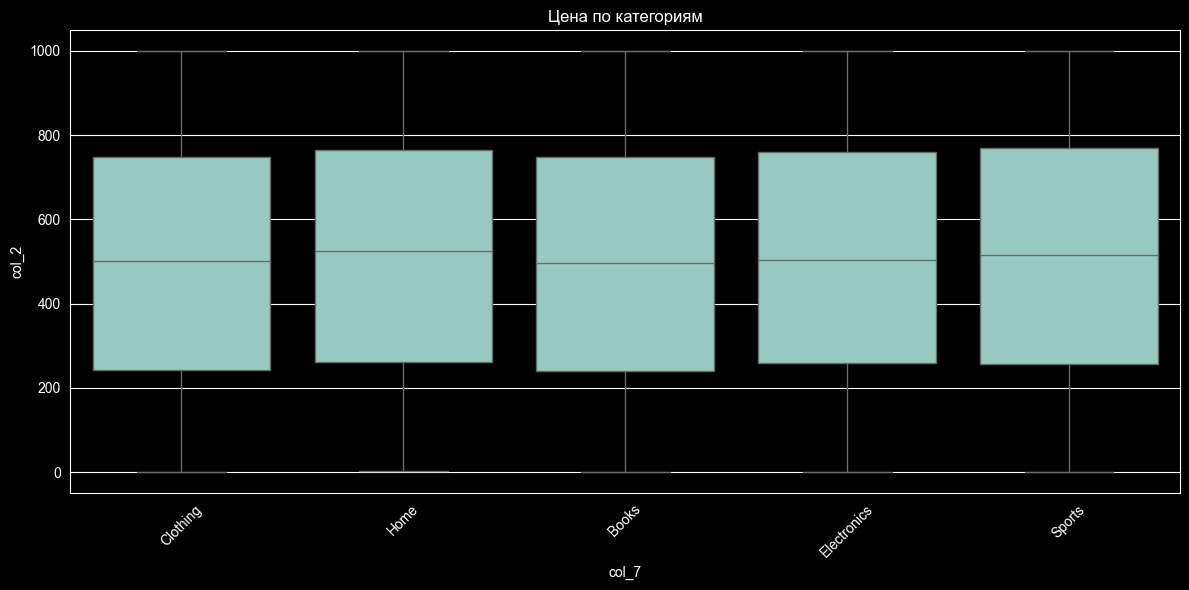

In [5]:
#4
plt.figure(figsize=(10, 5))
plt.hist(df['col_2'], bins=50, color='steelblue', edgecolor='white')
plt.title('Гистограмма цены')
plt.xlabel('Цена')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df['col_2'], df['col_3'], alpha=0.3, s=10)
plt.title('Цена vs Количество')
plt.xlabel('Цена (col_2)')
plt.ylabel('Количество (col_3)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='col_7', y='col_2')
plt.title('Цена по категориям')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [6]:
#5
mean_p = df['col_2'].mean()
std_p = df['col_2'].std()
anomalies = df[(df['col_2'] > mean_p + 3 * std_p) | (df['col_2'] < mean_p - 3 * std_p)]
print(f"Аномалий: {len(anomalies)}")
df = df[(df['col_2'] <= mean_p + 3 * std_p) & (df['col_2'] >= mean_p - 3 * std_p)]
print(f"После удаления аномалий: {df.shape}")
df['total_value'] = df['col_2'] * df['col_3']
df['log_price'] = np.log(df['col_2'])
df['double_stock'] = df['col_3'] * 2

Аномалий: 0
После удаления аномалий: (10000, 53)


In [7]:
#6
le = LabelEncoder()
df['col_7_encoded'] = le.fit_transform(df['col_7'].astype(str))
print(df[['col_7', 'col_7_encoded']].drop_duplicates())

          col_7  col_7_encoded
0      Clothing              1
2          Home              3
5         Books              0
10  Electronics              2
18       Sports              4


In [8]:
#7
feature_cols = [col for col in num_cols if col != 'col_2'] + ['total_value', 'log_price', 'double_stock', 'col_7_encoded']
feature_cols = [col for col in feature_cols if col in df.columns]

X = df[feature_cols]
y = df['col_2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (8000, 36), Test: (2000, 36)


In [9]:
#8
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
print(f"Линейная регрессия — MAE: {mae_lr:.2f}, MSE: {mse_lr:.2f}")


Линейная регрессия — MAE: 79.05, MSE: 11170.99


In [10]:
#9
extra_cols = ['total_value', 'double_stock', 'log_price', 'col_7_encoded']
X2 = df[[col for col in feature_cols if col in df.columns]]
y2 = df['col_2']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

lr2 = LinearRegression()
lr2.fit(X2_train, y2_train)
y2_pred = lr2.predict(X2_test)

mae_lr2 = mean_absolute_error(y2_test, y2_pred)
mse_lr2 = mean_squared_error(y2_test, y2_pred)
print(f"Улучшенная регрессия — MAE: {mae_lr2:.2f}, MSE: {mse_lr2:.2f}")

Улучшенная регрессия — MAE: 79.05, MSE: 11170.99


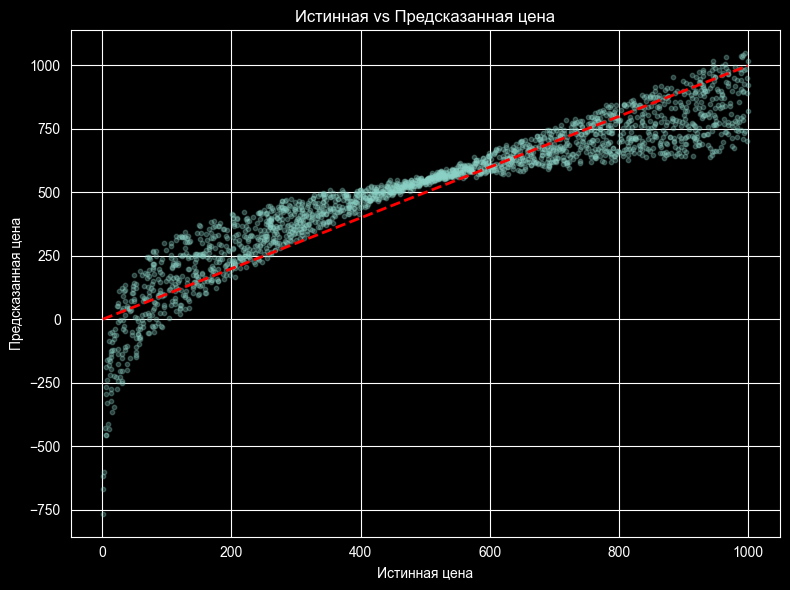

In [11]:
#10
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Истинная vs Предсказанная цена')
plt.xlabel('Истинная цена')
plt.ylabel('Предсказанная цена')
plt.tight_layout()
plt.show()

In [12]:
#11
scaler = StandardScaler()
scale_cols = [col for col in ['col_3', 'col_4', 'total_value', 'double_stock', 'log_price']
              if col in df.columns and pd.api.types.is_numeric_dtype(df[col])]
df_scaled = df.copy()
df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols].astype(float))
print(df_scaled[scale_cols].describe().round(2))

          col_3  total_value  double_stock  log_price
count  10000.00     10000.00      10000.00   10000.00
mean      -0.00        -0.00         -0.00       0.00
std        1.00         1.00          1.00       1.00
min       -1.73        -1.13         -1.73      -6.00
25%       -0.87        -0.83         -0.87      -0.39
50%        0.01        -0.30          0.01       0.32
75%        0.86         0.58          0.86       0.73
max        1.73         3.34          1.73       1.01


In [13]:
#12
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
importances = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values[:15], y=importances.index[:15])
plt.title('Важность признаков (Decision Tree)')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

y_pred_dt = dt.predict(X_test)
print(f"Decision Tree — MAE: {mean_absolute_error(y_test, y_pred_dt):.2f}")

Decision Tree — MAE: 7.71


In [14]:
#13
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train[scale_cols])
X_test_poly = poly.transform(X_test[scale_cols])

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)

print(f"Полиномиальная регрессия — MAE: {mean_absolute_error(y_test, y_pred_poly):.2f}, MSE: {mean_squared_error(y_test, y_pred_poly):.2f}")

Полиномиальная регрессия — MAE: 25.57, MSE: 1407.14


In [15]:
#14
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)

print(f"KNN — MAE: {mean_absolute_error(y_test, y_pred_knn):.2f}, MSE: {mean_squared_error(y_test, y_pred_knn):.2f}")


KNN — MAE: 151.29, MSE: 34136.05


In [16]:
#15
for cat in df['col_7'].unique():
    cat_df = df[df['col_7'] == cat]
    if len(cat_df) < 20:
        continue
    Xc = cat_df[[col for col in feature_cols if col in cat_df.columns]]
    yc = cat_df['col_2']
    Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42)
    lrc = LinearRegression()
    lrc.fit(Xc_train, yc_train)
    yc_pred = lrc.predict(Xc_test)
    print(f"{cat} — MAE: {mean_absolute_error(yc_test, yc_pred):.2f}")

Sports — MAE: 80.68


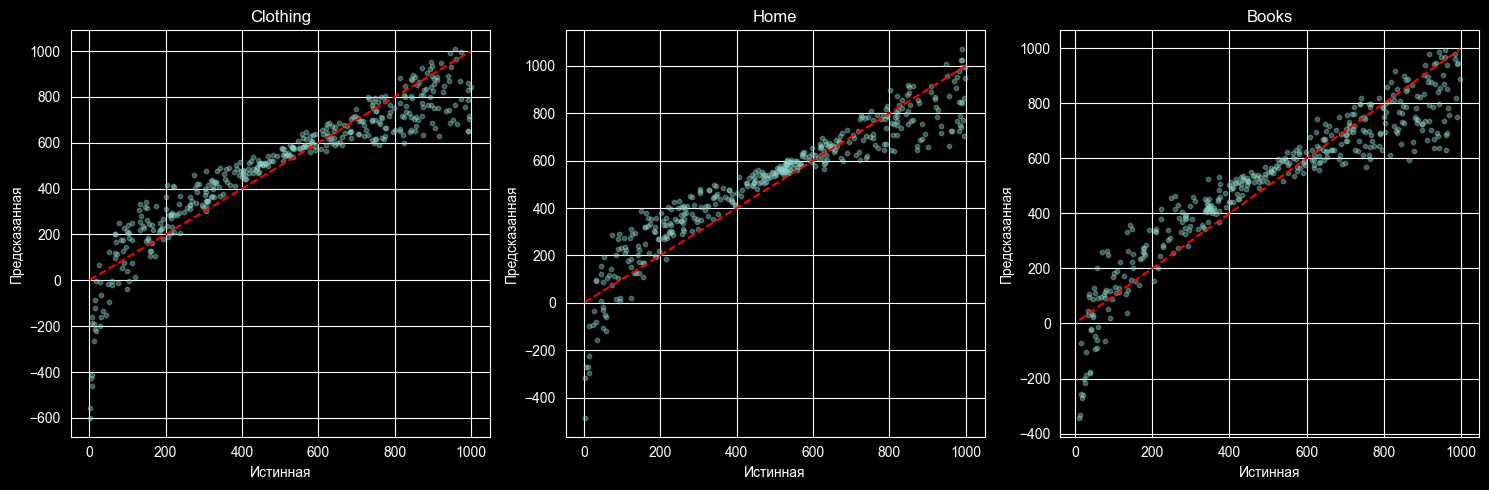

In [17]:
#16
fig, axes = plt.subplots(1, min(3, len(df['col_7'].unique())), figsize=(15, 5))
for ax, cat in zip(axes, df['col_7'].unique()[:3]):
    cat_df = df[df['col_7'] == cat]
    if len(cat_df) < 20:
        continue
    Xc = cat_df[[col for col in feature_cols if col in cat_df.columns]]
    yc = cat_df['col_2']
    Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42)
    lrc = LinearRegression()
    lrc.fit(Xc_train, yc_train)
    yc_pred = lrc.predict(Xc_test)
    ax.scatter(yc_test, yc_pred, alpha=0.4, s=10)
    ax.plot([yc_test.min(), yc_test.max()], [yc_test.min(), yc_test.max()], 'r--')
    ax.set_title(cat)
    ax.set_xlabel('Истинная')
    ax.set_ylabel('Предсказанная')
plt.tight_layout()
plt.show()

In [18]:
#17
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='neg_mean_absolute_error')
print(f"Кросс-валидация MAE: {-cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

Кросс-валидация MAE: 80.47 ± 2.27


In [19]:
#18
df['price_class'] = pd.cut(df['col_2'], bins=[0, 100, 500, float('inf')], labels=[0, 1, 2]).astype(int)
Xc = df[[col for col in feature_cols if col in df.columns]]
yc = df['price_class']
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(Xc_train, yc_train)
yc_pred = clf.predict(Xc_test)
print(f"Точность классификации: {accuracy_score(yc_test, yc_pred):.2f}")

Точность классификации: 1.00


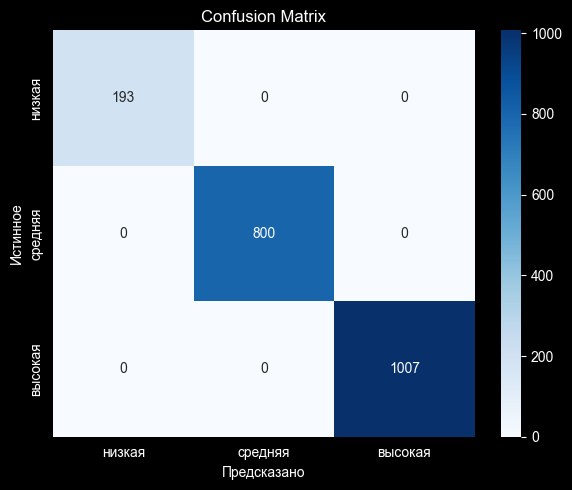

In [20]:
#19
cm = confusion_matrix(yc_test, yc_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['низкая', 'средняя', 'высокая'],
            yticklabels=['низкая', 'средняя', 'высокая'])
plt.title('Confusion Matrix')
plt.xlabel('Предсказано')
plt.ylabel('Истинное')
plt.tight_layout()
plt.show()

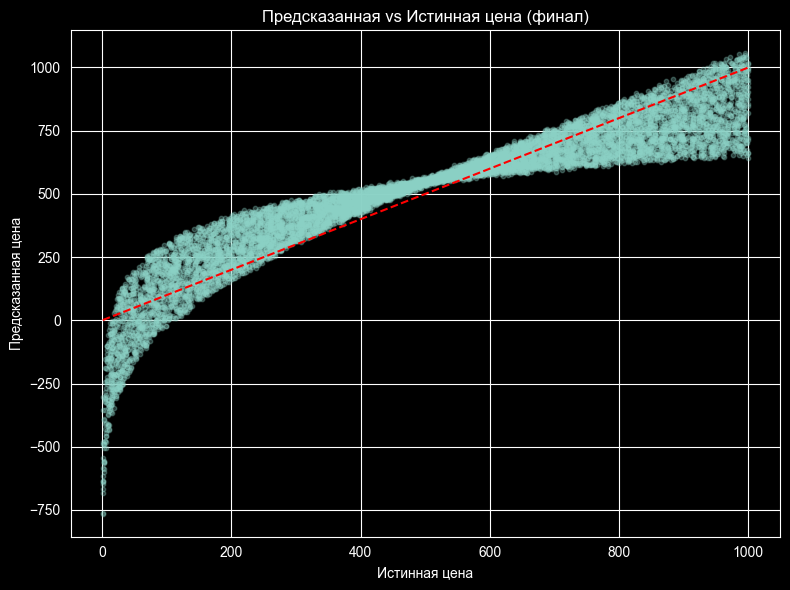

In [21]:
#20
df_result = df.copy()
df_result['predicted_price'] = lr.predict(df[[col for col in feature_cols if col in df.columns]])
df_result['predicted_class'] = clf.predict(df[[col for col in feature_cols if col in df.columns]])

df_result.to_excel('catalog_ml_predictions.xlsx', index=False)
print("Файл сохранён: catalog_ml_predictions.xlsx")

plt.figure(figsize=(8, 6))
plt.scatter(df_result['col_2'], df_result['predicted_price'], alpha=0.3, s=10)
plt.plot([df_result['col_2'].min(), df_result['col_2'].max()],
         [df_result['col_2'].min(), df_result['col_2'].max()], 'r--')
plt.title('Предсказанная vs Истинная цена (финал)')
plt.xlabel('Истинная цена')
plt.ylabel('Предсказанная цена')
plt.tight_layout()

plt.show()